In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

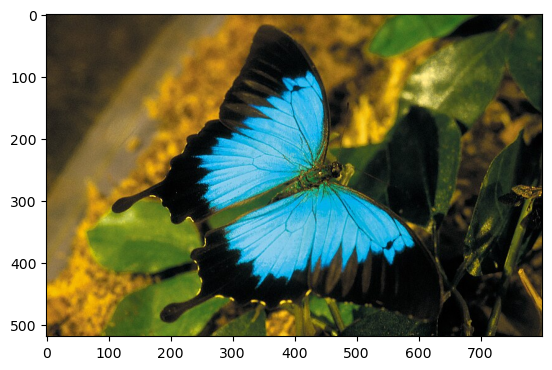

In [2]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')/255.0
plt.imshow(im[:,:,[2,1,0]])
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [3]:
def kmeans(im, iters=10, K=3, plot=False):
    
    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)
    
    H, W, C = im.shape

    # Convert image into an Nx3 vector of pixels
    pixels = im.reshape(-1, C)  # shape: (N, 3) where N = H*W
    N = pixels.shape[0]

    # Select K random colour centroids
    random_idx = np.random.choice(N, K, replace=False)
    centroids = pixels[random_idx].copy()  # shape: (K, 3)

    losses = []

    for j in range(1, iters):
        
        # Assign pixels to clusters
        # Compute squared Euclidean distance from every pixel to every centroid
        # pixels[:, np.newaxis, :] is (N,1,3), centroids[np.newaxis,:,:] is (1,K,3)
        # diff is (N,K,3), summing over colour axis gives (N,K) distance matrix
        diff = pixels[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        distances = np.sum(diff ** 2, axis=2)  # (N, K)
        cluster_indices = np.argmin(distances, axis=1)  # (N,) — nearest centroid index per pixel
        
        # Update centroid locations using new cluster assignments
        # New centroid = mean colour of all pixels assigned to that cluster
        for k in range(K):
            mask = (cluster_indices == k)
            if mask.sum() > 0:
                centroids[k] = pixels[mask].mean(axis=0)
        
        # Store the current loss
        # Loss = sum of squared distances from each pixel to its assigned centroid
        loss = np.sum(distances[np.arange(N), cluster_indices])
        losses.append(loss)
        
        # Convert cluster indices to an image
        cluster_idx_image = cluster_indices.reshape(H, W)
    
        # Create a quantised image using the clustering
        # Replace each pixel with the colour of its assigned centroid
        quantised_image = centroids[cluster_indices].reshape(H, W, C)
        
        # You may want to visualise the current progress of kmeans for debugging purposes
        if plot:
            plt.subplot(1,2,1)
            plt.imshow(cluster_idx_image, cmap='tab20')
            plt.subplot(1,2,2)
            plt.imshow(np.clip(quantised_image, 0, 1))
            plt.show()
        
    # Convert cluster indices to an image
    cluster_idx_image = cluster_indices.reshape(H, W)
    
    # Create a quantised image using the clustering
    quantised_image = centroids[cluster_indices].reshape(H, W, C)

    return losses, cluster_idx_image, quantised_image

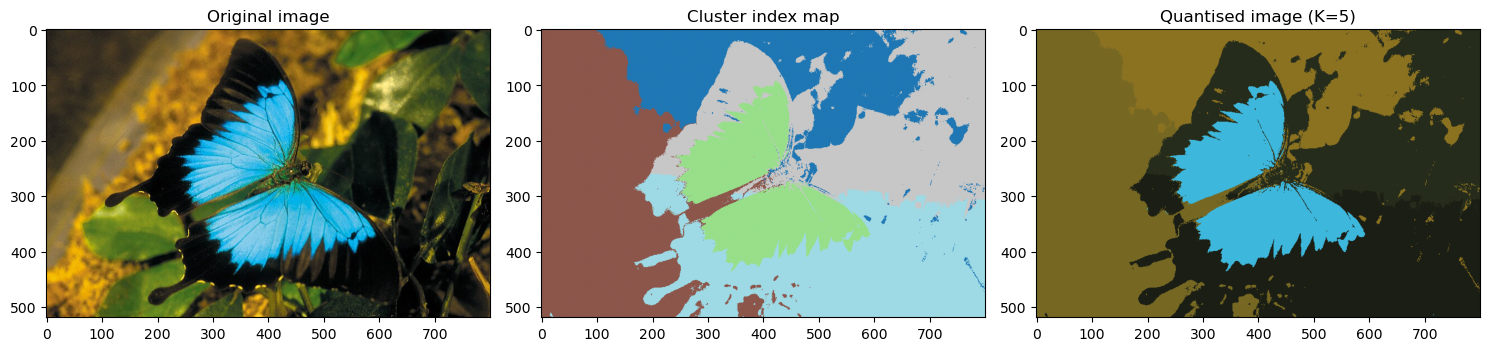

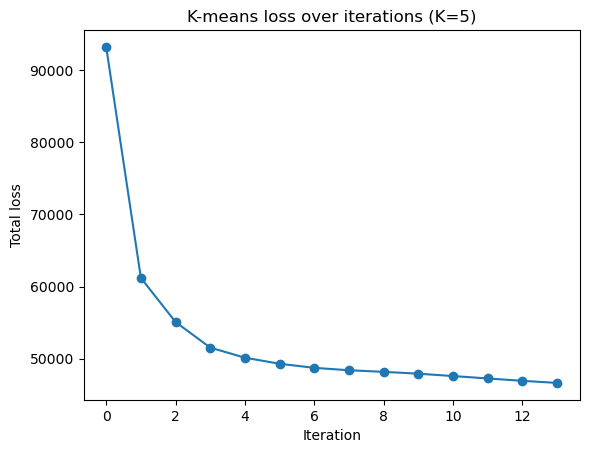

In [17]:
# Test your function using the image provided
# Test your function using the image provided
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg') / 255.0
im_rgb = im[:, :, [2, 1, 0]]  # OpenCV loads BGR, convert to RGB for display

losses, cluster_idx_image, quantised_image = kmeans(im_rgb, iters=15, K=5)

# Display original, cluster map, and quantised image side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(im_rgb)
axes[0].set_title('Original image')
axes[1].imshow(cluster_idx_image, cmap='tab20')
axes[1].set_title('Cluster index map')
axes[2].imshow(np.clip(quantised_image, 0, 1))
axes[2].set_title('Quantised image (K=5)')
plt.tight_layout()
plt.show()

# Plot the loss curve to verify convergence — should flatten out over iterations
plt.plot(losses, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Total loss')
plt.title('K-means loss over iterations (K=5)')
plt.show()

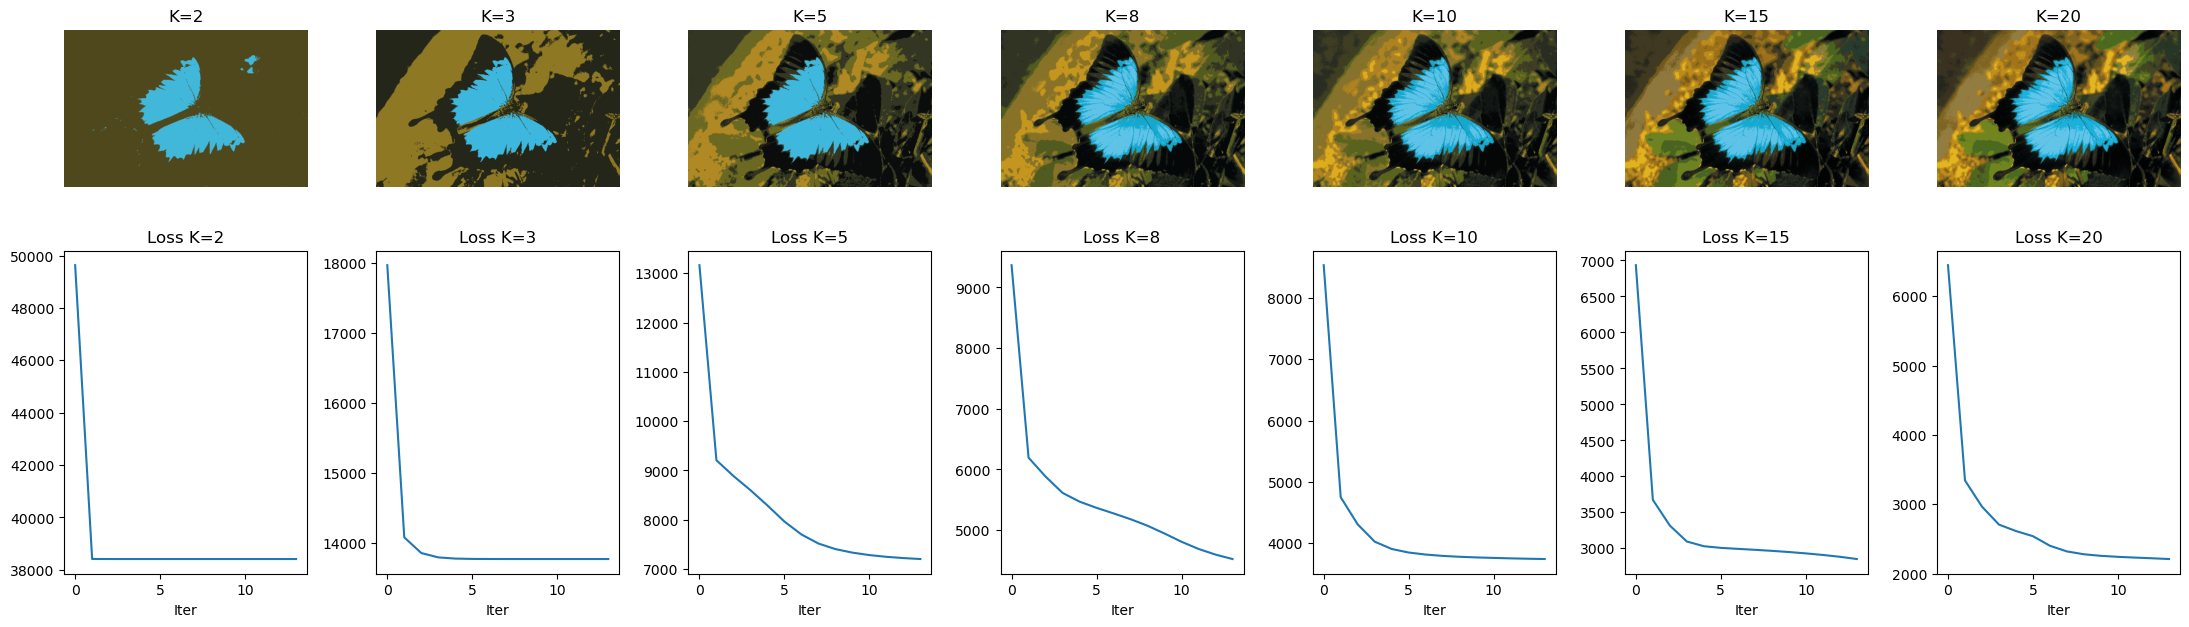

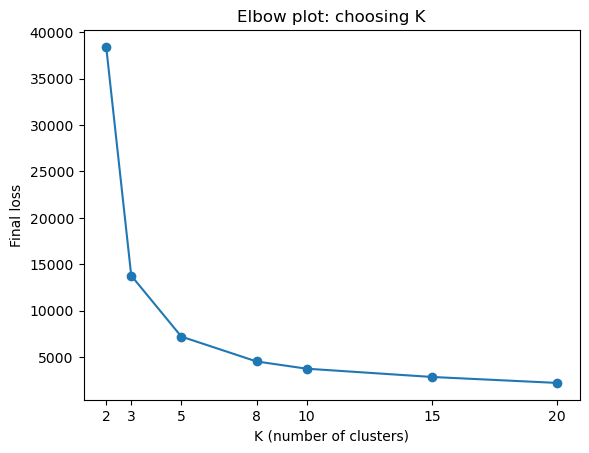

In [5]:
# Select an appropriate value for K and use visualisations to show how you did this
# Select an appropriate value for K and use visualisations to show how you did this

K_values = [2, 3, 5, 8, 10, 15, 20]
final_losses = []

fig, axes = plt.subplots(2, len(K_values), figsize=(22, 7))

for i, K in enumerate(K_values):
    losses, cluster_idx_image, quantised_image = kmeans(im_rgb, iters=15, K=K)
    final_losses.append(losses[-1])
    
    axes[0][i].imshow(np.clip(quantised_image, 0, 1))
    axes[0][i].set_title(f'K={K}')
    axes[0][i].axis('off')
    
    axes[1][i].plot(losses)
    axes[1][i].set_title(f'Loss K={K}')
    axes[1][i].set_xlabel('Iter')

plt.tight_layout()
plt.show()

# Elbow plot — look for where the loss stops decreasing rapidly
plt.plot(K_values, final_losses, marker='o')
plt.xlabel('K (number of clusters)')
plt.ylabel('Final loss')
plt.title('Elbow plot: choosing K')
plt.xticks(K_values)
plt.show()

# K~5-8 is typically the elbow for this image — good balance of detail vs simplicity

### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

In [6]:
def kmeans(im, iters=10, K=3, scale=1, plot=False):
    
    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)
    
    H, W, C = im.shape

    # Convert image into an Nx3 vector of pixels
    pixels = im.reshape(-1, C)  # shape: (N, 3), RGB values already in [0,1]
    N = pixels.shape[0]

    # Build normalised pixel coordinate grid, values in [0,1]
    rows, cols = np.indices((H, W))
    norm_rows = rows.reshape(-1, 1) / H  # (N, 1)
    norm_cols = cols.reshape(-1, 1) / W  # (N, 1)

    # Scale the COLOUR features — higher scale gives more weight to colour (more detail),
    # lower scale lets spatial location dominate (more compact, connected superpixels).
    # scale=0 → pure spatial clustering; scale >> 1 → approaches colour-only (Task 1)
    scaled_pixels = pixels * scale  # (N, 3)

    # Concatenate scaled colour and spatial features into a single feature vector
    features = np.hstack([scaled_pixels, norm_rows, norm_cols])  # (N, 5)

    # Select K random centroids initialised from pixel feature vectors
    random_idx = np.random.choice(N, K, replace=False)
    centroids = features[random_idx].copy()  # shape: (K, 5)

    losses = []

    for j in range(1, iters):
        
        # Assign pixels to clusters
        diff = features[:, np.newaxis, :] - centroids[np.newaxis, :, :]  # (N, K, 5)
        distances = np.sum(diff ** 2, axis=2)  # (N, K)
        cluster_indices = np.argmin(distances, axis=1)  # (N,)
        
        # Update centroid locations using new cluster assignments
        for k in range(K):
            mask = (cluster_indices == k)
            if mask.sum() > 0:
                centroids[k] = features[mask].mean(axis=0)
        
        # Store the current loss
        loss = np.sum(distances[np.arange(N), cluster_indices])
        losses.append(loss)
        
        # Convert cluster indices to an image
        cluster_idx_image = cluster_indices.reshape(H, W)
    
        # Create a quantised image using the clustering
        # Divide first 3 centroid dims back by scale to recover true RGB for display
        quantised_image = (centroids[cluster_indices, :3] / scale).reshape(H, W, C)
        
        if plot:
            plt.subplot(1,2,1)
            plt.imshow(cluster_idx_image, cmap='tab20')
            plt.subplot(1,2,2)
            plt.imshow(np.clip(quantised_image, 0, 1))
            plt.show()
        
    # Convert cluster indices to an image
    cluster_idx_image = cluster_indices.reshape(H, W)
    
    # Create a quantised image using the clustering
    quantised_image = (centroids[cluster_indices, :3] / scale).reshape(H, W, C)

    return losses, cluster_idx_image, quantised_image

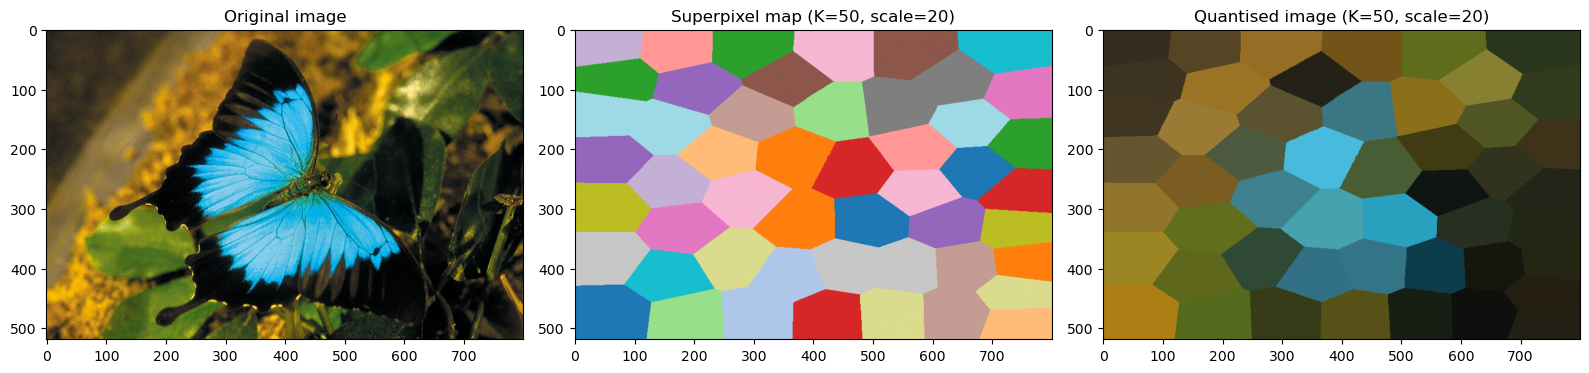

In [7]:
# Visualise your superpixel clustering for different scaling parameters 
# Use your kmeans function to cluster based on colour and location
# scale=20 is a reasonable starting point — spatial features are weighted alongside colour
losses, cluster_idx_image, quantised_image = kmeans(im_rgb, iters=15, K=50, scale=20*0.001)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(im_rgb)
axes[0].set_title('Original image')
axes[1].imshow(cluster_idx_image, cmap='tab20')
axes[1].set_title('Superpixel map (K=50, scale=20)')
axes[2].imshow(np.clip(quantised_image, 0, 1))
axes[2].set_title('Quantised image (K=50, scale=20)')
plt.tight_layout()
plt.show()

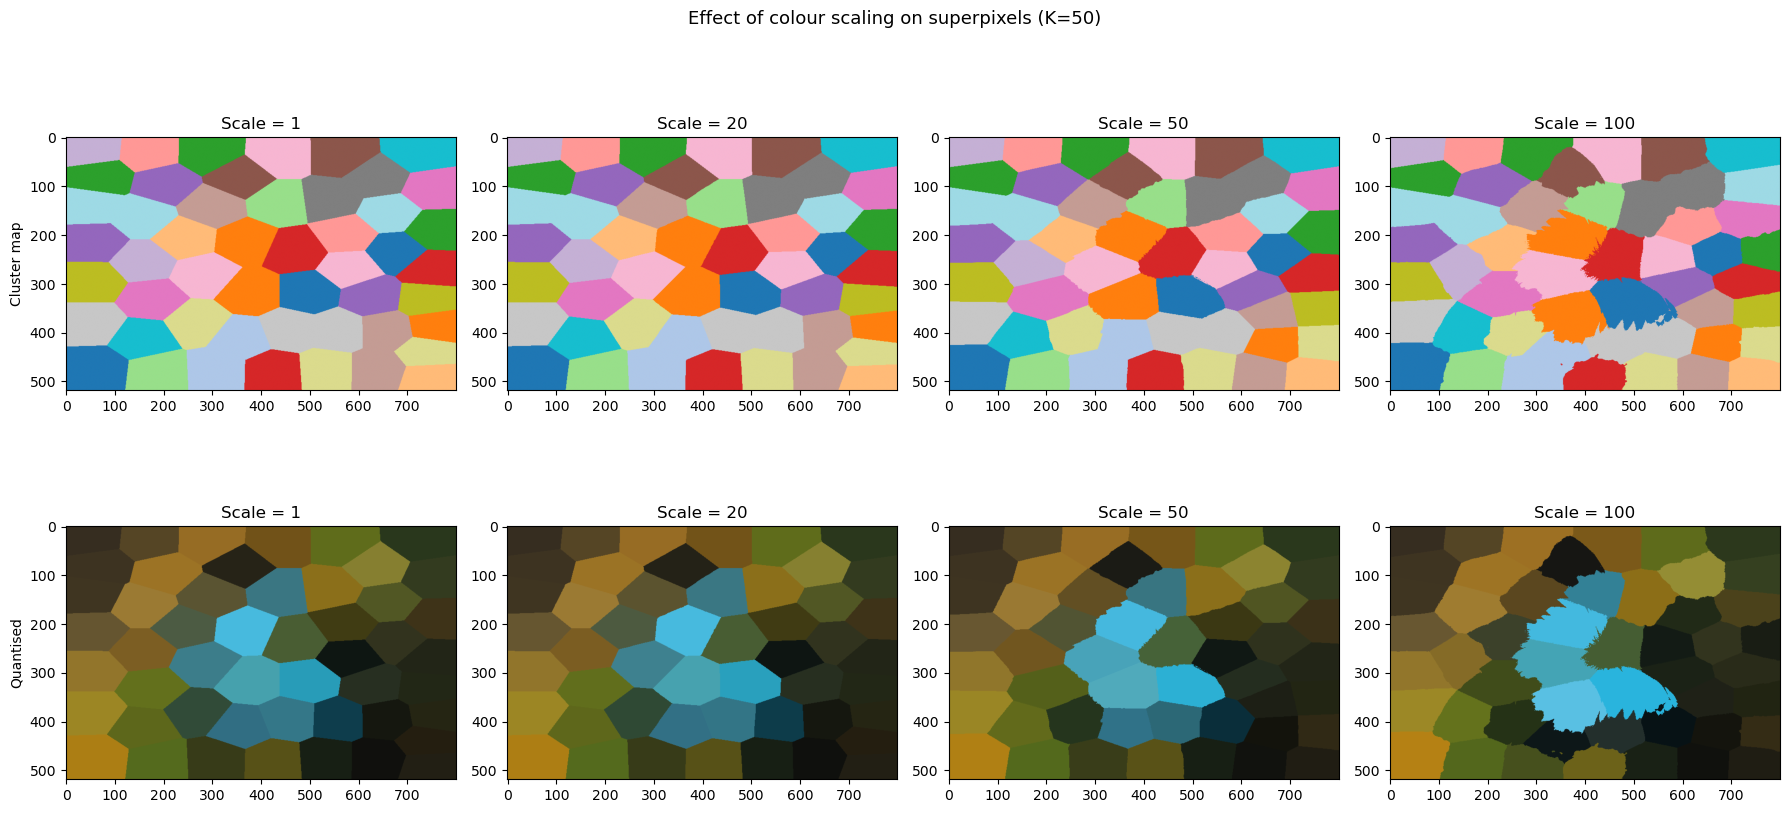

In [8]:
# Visualise your superpixel clustering for different scaling parameters
# Low scale → spatial location dominates → compact, connected superpixels
# High scale → colour dominates → detailed but spatially scattered (like Task 1)
# We want a low-enough scale that superpixels stay connected, but high enough to
# respect colour boundaries

scale_values = [1, 20, 50, 100]

fig, axes = plt.subplots(2, len(scale_values), figsize=(18, 9))

for i, scale in enumerate(scale_values):
    losses, cluster_idx_image, quantised_image = kmeans(im_rgb, iters=15, K=50, scale=scale*0.001)
    
    axes[0][i].imshow(cluster_idx_image, cmap='tab20')
    axes[0][i].set_title(f'Scale = {scale}')
    axes[0][i].set_ylabel('Cluster map' if i == 0 else '')
    
    axes[1][i].imshow(np.clip(quantised_image, 0, 1))
    axes[1][i].set_title(f'Scale = {scale}')
    axes[1][i].set_ylabel('Quantised' if i == 0 else '')

plt.suptitle('Effect of colour scaling on superpixels (K=50)', fontsize=13)
plt.tight_layout()
plt.show()

## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


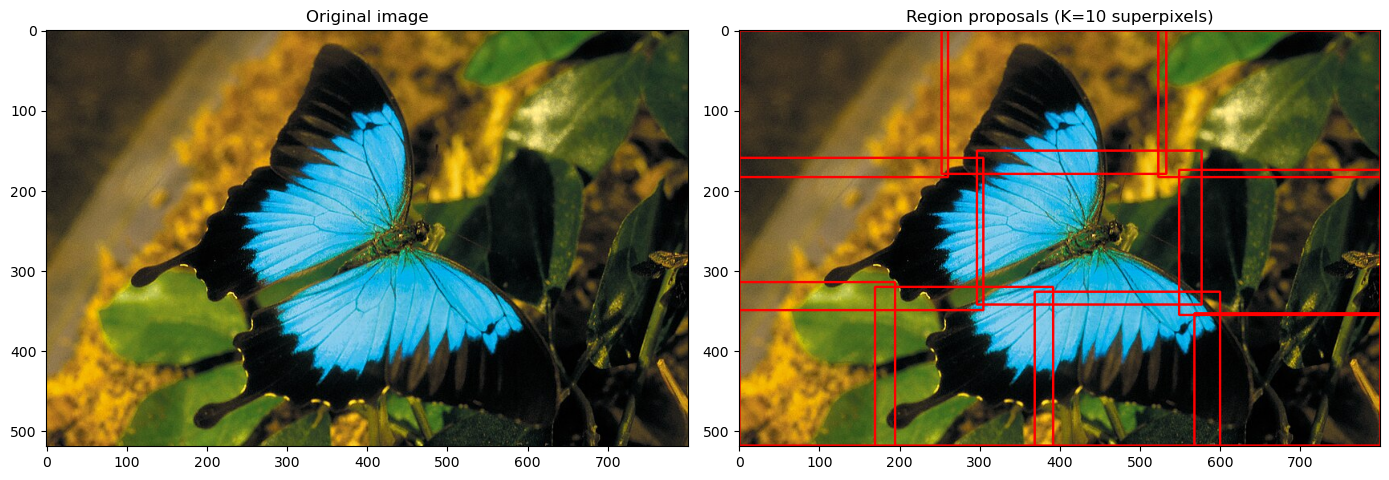

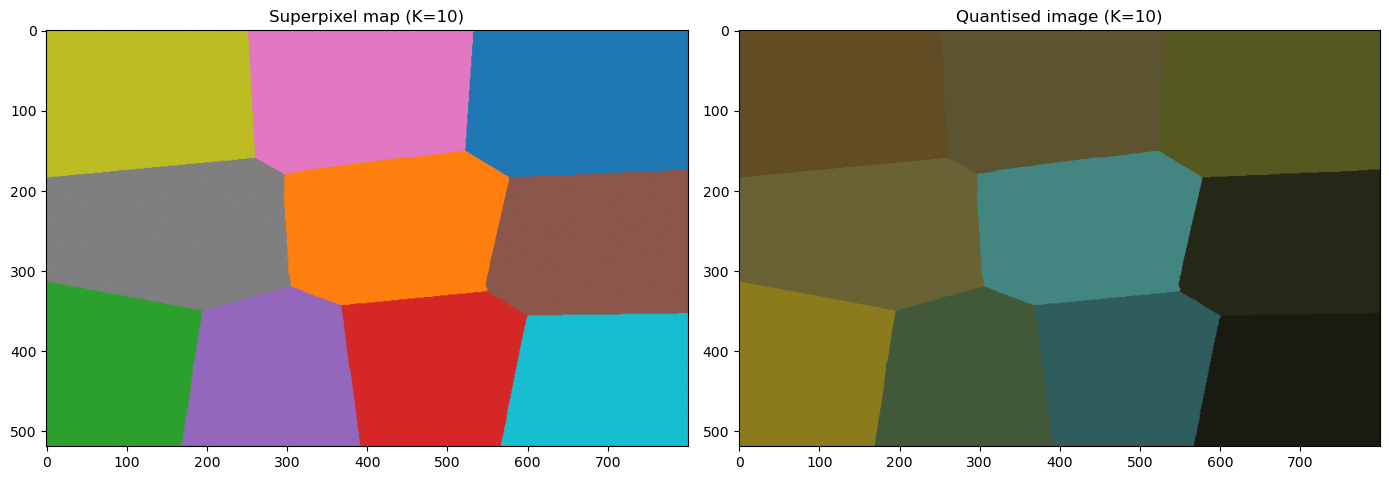

In [13]:
# Visualise your regions on the original image

# Visualise your regions on the original image

# Segment into 10 superpixels using a balanced scale
losses, cluster_idx_image, quantised_image = kmeans(im_rgb, iters=15, K=10, scale=50*0.001)

# Convert original image back to uint8 BGR for cv2.rectangle
im_draw = np.ascontiguousarray((im_rgb * 255).astype(np.uint8)[:, :, [2, 1, 0]])

# For each superpixel, find the bounding box (top-left and bottom-right pixels)
for k in range(10):
    # Get all pixel positions belonging to superpixel k
    # np.where returns (row_indices, col_indices) for pixels where condition is True
    rows, cols = np.where(cluster_idx_image == k)
    
    if len(rows) == 0:
        continue  # skip if a cluster ended up empty
    
    # Top-left is the minimum row and column; bottom-right is the maximum
    top_left     = (int(cols.min()), int(rows.min()))  # cv2 uses (x, y) = (col, row)
    bottom_right = (int(cols.max()), int(rows.max()))

    
    
    # Draw rectangle on the image — each superpixel gets a distinct colour
    colour = (0, 0, 255)
    cv2.rectangle(im_draw, top_left, bottom_right, colour, 2)



# Convert back to RGB for Matplotlib display
im_draw_rgb = im_draw[:, :, [2, 1, 0]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(im_rgb)
axes[0].set_title('Original image')
axes[1].imshow(im_draw_rgb)
axes[1].set_title('Region proposals (K=10 superpixels)')
plt.tight_layout()
plt.show()

# Display superpixel map and quantised image
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cluster_idx_image, cmap='tab10')
axes[0].set_title('Superpixel map (K=10)')
axes[1].imshow(np.clip(quantised_image, 0, 1))
axes[1].set_title('Quantised image (K=10)')
plt.tight_layout()
plt.show()

## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.
